# Notebook 4: Model and Tool Analysis

**Goal:** Compare models and tools without hiding uncertainty or repository imbalance.

**Inputs:** `evaluation_attempts.csv`, `evaluation_candidates.csv`, `evaluation_repositories.csv`

**RQs addressed:** RQ5

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from analysis.statistics import bootstrap_ci, repository_blocked_bootstrap
from analysis.plots import (
    metric_delta_distribution,
    cost_vs_improvement_scatter,
    robustness_heatmap,
)

sns.set_theme(style='whitegrid')

DATA_DIR   = Path('../data')
REQUIRED_FILES = ['evaluation_attempts.csv', 'evaluation_candidates.csv']
missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis CSVs in {DATA_DIR}: {missing}')
attempts   = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv')
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
repos      = pd.read_csv(DATA_DIR / 'evaluation_repositories.csv') if (DATA_DIR / 'evaluation_repositories.csv').exists() else pd.DataFrame()

## 1. Model / Tool Participation and Data Completeness

Lists which models and tools ran, how many attempts each produced, and whether any configuration (model, tool, repository) has disproportionately few observations. Imbalanced participation limits what can be concluded from later comparisons.


In [2]:
# LLM models
llm = attempts[attempts.get('lane', pd.Series()) == 'llm']
if 'model' in llm.columns:
    print('LLM models:')
    print(llm.groupby('model').size().sort_values(ascending=False))

# Agentic tools
agentic = attempts[attempts.get('lane', pd.Series()) == 'agentic']
if 'tool_id' in agentic.columns:
    print('\nAgentic tools:')
    print(agentic.groupby('tool_id').size().sort_values(ascending=False))

LLM models:
model
gpt-oss-120b    6
dtype: int64

Agentic tools:
tool_id
codex     2
gemini    2
dtype: int64


## 2. Outcome Rates with Confidence Intervals

Reports success rate per model/tool with 95% bootstrap CIs (percentile method, 9999 resamples).

**Interpretation.** These are **estimation intervals**, not hypothesis test results — overlapping CIs do not directly imply non-significance. At the current sample sizes (typically 2–6 attempts per model/tool), bootstrap CIs are wide and should be treated as descriptive. No formal comparison is made here; Section 6 picks the apparent "best" purely by point estimate.

**Multiple comparisons.** With several models and tools measured on multiple metrics, the expected number of spurious top-rankers grows. Any comparison drawn from this section is **exploratory** and requires replication before being reported as a confirmed finding.

VEP rate (test passed **and** metrics improved ≥ noise floor) is reported alongside `validated_success` as the primary practical-impact measure.


In [ ]:
from analysis.statistics import bootstrap_ci, bonferroni_correct, mann_whitney_u

def ci_for_group(df, group_col, metric_col='validated_success'):
    rows = []
    for grp, sub in df.groupby(group_col):
        vals = sub[metric_col].dropna().astype(float)
        if len(vals) < 2:
            rows.append({'group': grp, 'n': len(vals),
                         'mean': float(vals.mean()) if len(vals) else float('nan'),
                         'ci_lower': float('nan'), 'ci_upper': float('nan')})
            continue
        ci = bootstrap_ci(vals, stat_fn=np.mean)
        rows.append({'group': grp, 'n': len(vals), 'mean': ci.estimate,
                     'ci_lower': ci.lower, 'ci_upper': ci.upper})
    return pd.DataFrame(rows).sort_values('mean', ascending=False)


def pairwise_bonferroni(df, group_col, metric_col='validated_success', alpha=0.05):
    """Pairwise Mann-Whitney U with Bonferroni correction across all group pairs."""
    groups = sorted(df[group_col].dropna().unique())
    if len(groups) < 2:
        print(f'Only {len(groups)} group(s) -- no pairwise comparison possible.')
        return
    pairs = [(a, b) for i, a in enumerate(groups) for b in groups[i+1:]]
    p_values, labels, effects = [], [], []
    for a, b in pairs:
        x = df[df[group_col] == a][metric_col].dropna().astype(float)
        y = df[df[group_col] == b][metric_col].dropna().astype(float)
        res = mann_whitney_u(x, y)
        p_values.append(res.p_value)
        labels.append(f'{a} vs {b}')
        effects.append(round(res.effect_size, 3))
    corr = bonferroni_correct(p_values, alpha=alpha)
    col_sig = f"sig (Bonferroni alpha={corr['alpha_corrected']:.4f})"
    pw = pd.DataFrame({
        'comparison': labels,
        'p_value': [round(p, 4) for p in p_values],
        "Cliff's delta": effects,
        col_sig: corr['reject'],
    })
    print(f"Bonferroni: alpha={alpha} / k={corr['k']} -> threshold={corr['alpha_corrected']:.4f}")
    display(pw)


if 'model' in llm.columns and 'validated_success' in llm.columns:
    model_ci = ci_for_group(llm, 'model')
    if 'validated_evidence_positive' in llm.columns:
        vep_ci = ci_for_group(llm, 'model', 'validated_evidence_positive').rename(
            columns={'mean': 'vep_rate', 'ci_lower': 'vep_lower', 'ci_upper': 'vep_upper', 'n': 'n_vep'})
        model_ci = model_ci.merge(vep_ci[['group', 'vep_rate', 'vep_lower', 'vep_upper']], on='group', how='left')
    display(model_ci)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(model_ci['group'], model_ci['mean'],
            xerr=[model_ci['mean'] - model_ci['ci_lower'],
                  model_ci['ci_upper'] - model_ci['mean']],
            capsize=4, color='steelblue', alpha=0.8)
    ax.set_xlabel('Success rate (validated_success)')
    ax.set_title('LLM model success rate with 95% bootstrap CI (exploratory -- small n)')
    plt.tight_layout()
    plt.show()

    pairwise_bonferroni(llm, 'model')


,group,n,mean,ci_lower,ci_upper
0,codex,2,1.0,1.0,1.0
1,gemini,2,0.5,0.0,1.0


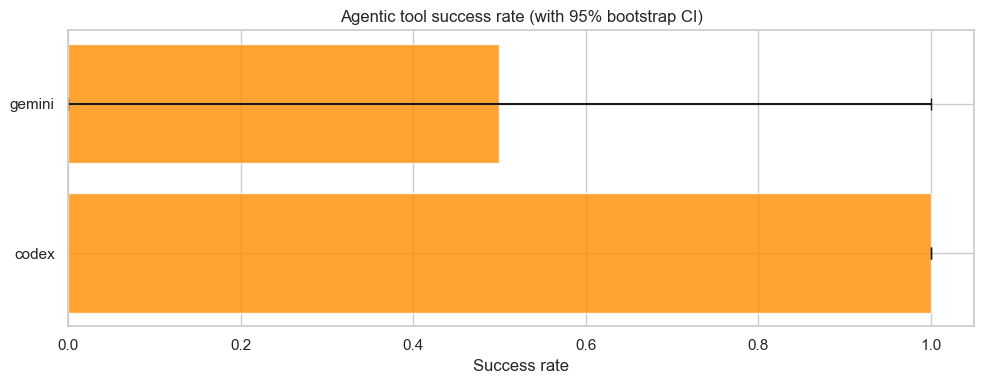

In [4]:
if 'tool_id' in agentic.columns and 'validated_success' in agentic.columns:
    tool_ci = ci_for_group(agentic, 'tool_id')
    display(tool_ci)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(tool_ci['group'], tool_ci['mean'],
            xerr=[tool_ci['mean'] - tool_ci['ci_lower'],
                  tool_ci['ci_upper'] - tool_ci['mean']],
            capsize=4, color='darkorange', alpha=0.8)
    ax.set_xlabel('Success rate')
    ax.set_title('Agentic tool success rate (with 95% bootstrap CI)')
    plt.tight_layout()
    plt.show()

    pairwise_bonferroni(agentic, 'tool_id')


## 3. Metric Improvements

Distribution of coverage and mutation score deltas per model/tool, plotted as boxplots. Only attempts with non-missing deltas are shown — failed attempts that produced no measurement are excluded, so the distributions are conditional on output being generated. Interpret alongside Section 2 success rates.


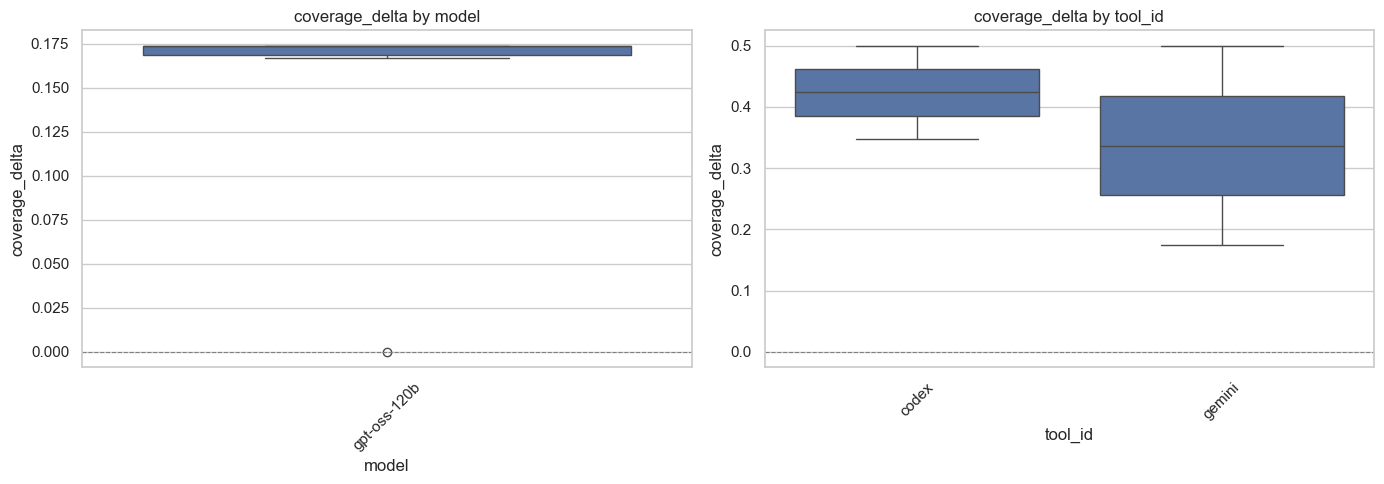

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'model' in llm.columns and 'coverage_delta' in llm.columns:
    metric_delta_distribution(llm, 'coverage_delta', 'model', ax=axes[0])
if 'tool_id' in agentic.columns and 'coverage_delta' in agentic.columns:
    metric_delta_distribution(agentic, 'coverage_delta', 'tool_id', ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Cost Efficiency

Normalises validated successes by token consumption (successes per 1k tokens) to compare productivity independent of attempt count. A model with a lower success rate but far fewer tokens per attempt could still be more cost-efficient overall.


In [6]:
# Validated successes per 1k tokens (where token data available)
for label, df, group_col in [('LLM models', llm, 'model'), ('Agentic tools', agentic, 'tool_id')]:
    if group_col in df.columns and 'total_tokens' in df.columns and 'validated_success' in df.columns:
        eff = df.groupby(group_col).apply(
            lambda g: g['validated_success'].sum() / (g['total_tokens'].sum() / 1000)
            if g['total_tokens'].sum() > 0 else float('nan')
        )
        print(f'{label} — successes per 1k tokens:')
        print(eff.sort_values(ascending=False))

LLM models — successes per 1k tokens:
model
gpt-oss-120b    0.014768
dtype: float64
Agentic tools — successes per 1k tokens:
tool_id
codex     0.006734
gemini    0.002999
dtype: float64


## 5. Robustness Across Repositories

Heatmap of success rate per model/tool × repository. With only 2 repositories, this diagnoses whether any apparent advantage is driven by a single codebase rather than generalising. A model that dominates on one repository but fails on the other is not robust.


C:\Users\milit\AppData\Local\Temp\ipykernel_42412\2665552197.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


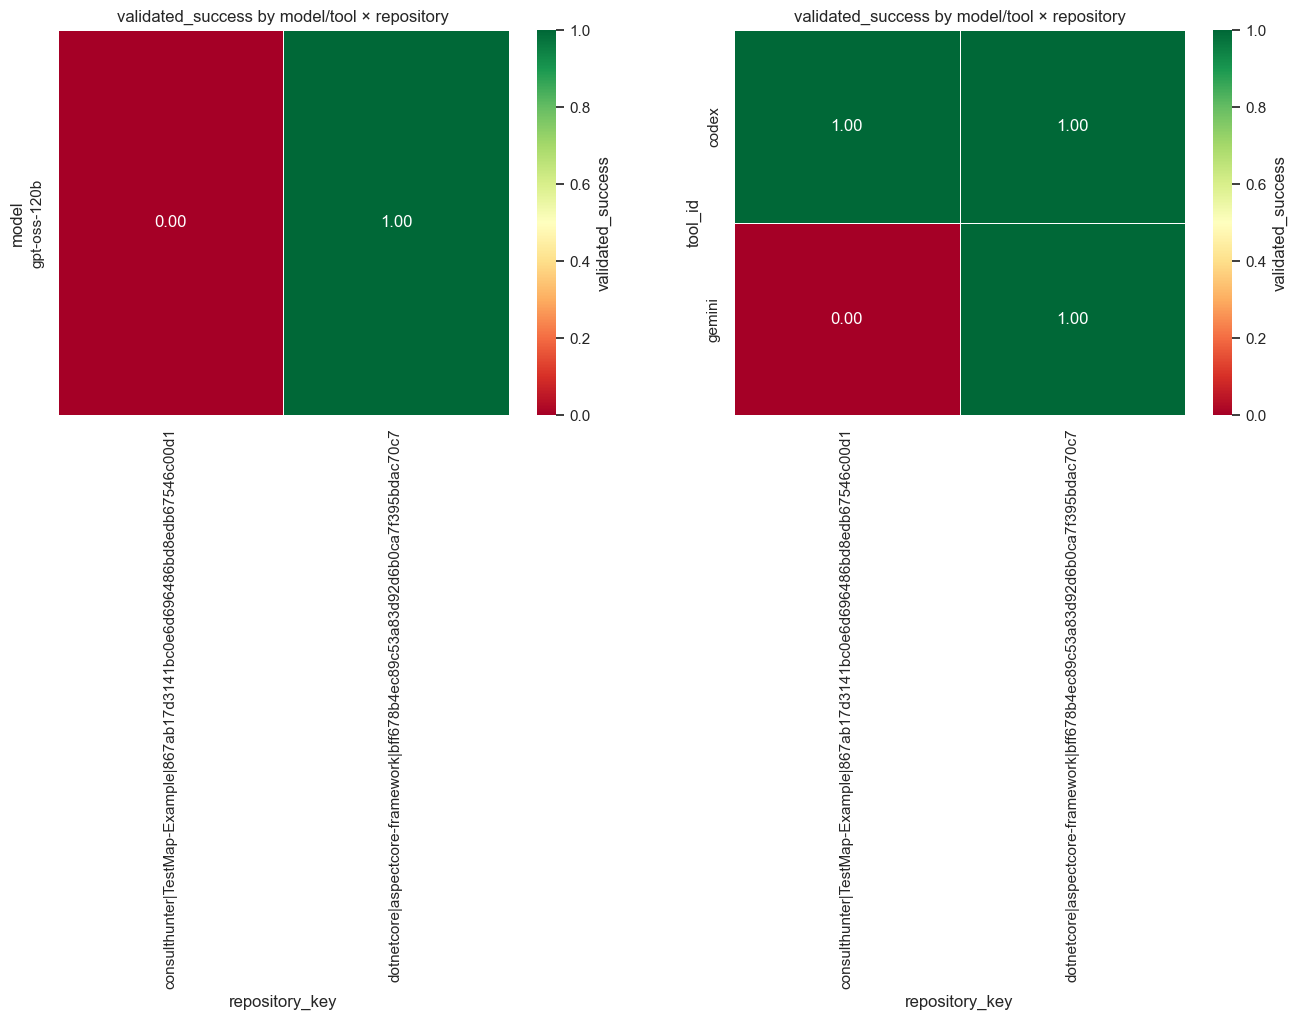

In [7]:
# Robustness heatmap: model/tool × repository
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'model' in llm.columns and 'repository_key' in llm.columns and 'validated_success' in llm.columns:
    robustness_heatmap(llm, 'model', 'repository_key', 'validated_success', ax=axes[0])

if 'tool_id' in agentic.columns and 'repository_key' in agentic.columns and 'validated_success' in agentic.columns:
    robustness_heatmap(agentic, 'tool_id', 'repository_key', 'validated_success', ax=axes[1])

plt.tight_layout()
plt.show()

## 6. Best-by-Category Summary

Ranks models and tools by point-estimate mean per metric category. **Treat as hypothesis generation only:** at this sample size, rankings are unstable and would reverse with a small number of additional attempts. Any "winner" identified here should be confirmed with a larger evaluation before being reported as a finding.


In [8]:
# Scaffold: fill in once all metric columns are confirmed
categories = {
    'best_overall':       ('validated_success', attempts),
    'best_coverage':      ('coverage_delta',    attempts),
    'best_mutation':      ('mutation_score_delta', attempts),
}

results = []
for category, (metric, df) in categories.items():
    for producer_col in ('model', 'tool_id'):
        if producer_col in df.columns and metric in df.columns:
            best = df.groupby(producer_col)[metric].mean().idxmax()
            score = df.groupby(producer_col)[metric].mean().max()
            results.append({'category': category, 'producer_col': producer_col, 'winner': best, 'score': score})

pd.DataFrame(results)

,category,producer_col,winner,score
0,best_overall,model,gpt-5.1,1.000000
1,best_overall,tool_id,codex,1.000000
2,best_coverage,model,gpt-5.1,0.423913
3,best_coverage,tool_id,codex,0.423913
4,best_mutation,model,gemini-2.5-pro,6.248115
5,best_mutation,tool_id,gemini,6.248115


## 7. Outcome Classification by Model/Tool

Full outcome breakdown per model/tool as a stacked bar, showing the proportion reaching each stage (ValidatedEvidencePositive, ValidatedLowImpact, FailedEvidencePositive, BuildFailed, etc.). This is more diagnostic than the binary success rate because it reveals where each model/tool tends to fail.


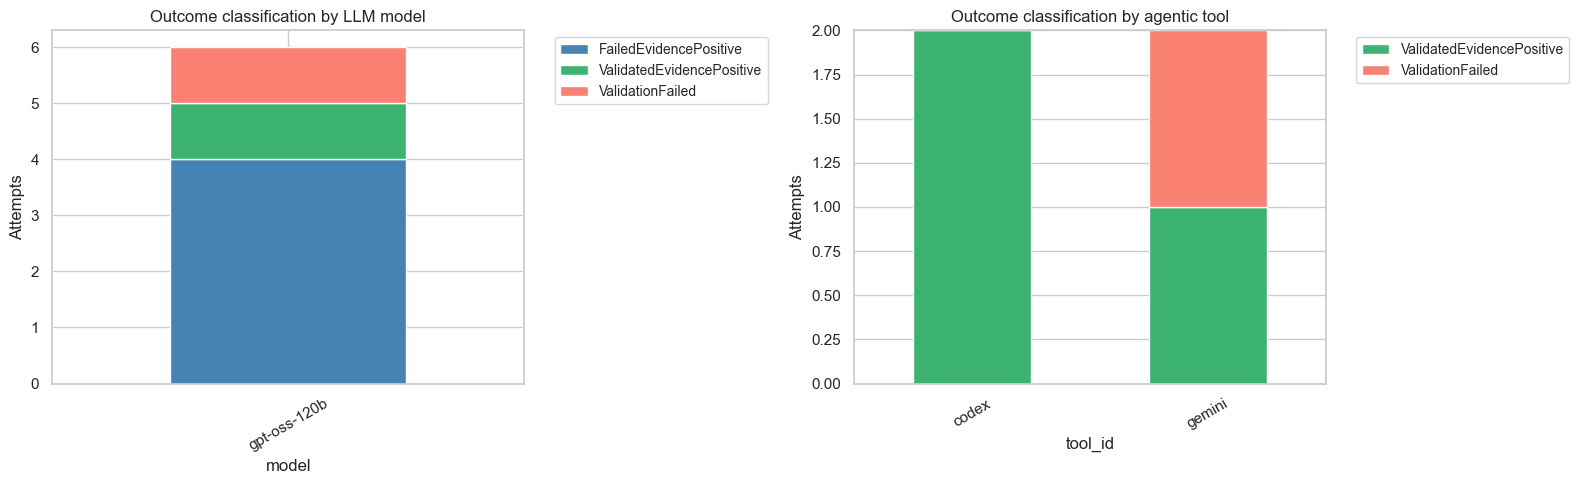

In [9]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in attempts.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    if 'model' in llm.columns:
        outcome_classification_bar(llm, group_col='model', ax=axes[0])
        axes[0].set_title('Outcome classification by LLM model')
    if 'tool_id' in agentic.columns:
        outcome_classification_bar(agentic, group_col='tool_id', ax=axes[1])
        axes[1].set_title('Outcome classification by agentic tool')
    plt.tight_layout()
    plt.show()
else:
    print('outcome_classification column not found.')

## 8. Success Predictors: Complexity, Coverage, and Access Strategy

Checks whether success correlates with the difficulty of the target method across three candidate predictors: cyclomatic complexity (CC) quartiles, baseline coverage bucket (low / mid / high), and access strategy. A tool that only succeeds on easy methods (simple code, already well-covered, direct access) is less useful in practice than one that handles harder candidates. Point-biserial correlations are reported for all available source metrics.


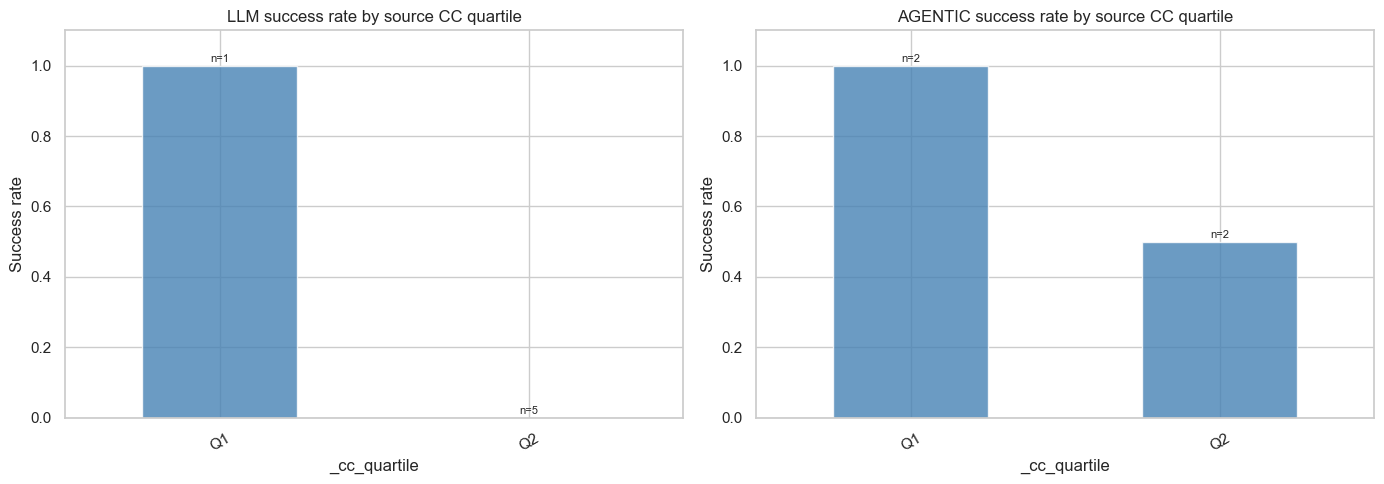


Correlation with validated_success:
source_method_sloc                -0.802
source_method_cc                  -0.802
source_method_baseline_coverage   -0.802
source_method_coupling             0.802
source_method_mi                   0.802
Name: validated_success, dtype: float64


In [10]:
import numpy as np

# -- Cyclomatic complexity quartiles --------------------------------------
if 'source_method_cc' in attempts.columns and 'validated_success' in attempts.columns:
    cc_vals = attempts['source_method_cc'].dropna().reindex(attempts.index)
    try:
        _, bins = pd.qcut(cc_vals.dropna(), q=4, retbins=True, duplicates='drop')
        n_bins = len(bins) - 1
        labels = [f'Q{i+1}' for i in range(n_bins)] if n_bins > 1 else None
        attempts['_cc_quartile'] = pd.cut(cc_vals, bins=bins, labels=labels, include_lowest=True)
    except ValueError:
        attempts['_cc_quartile'] = pd.NA

    valid = attempts.dropna(subset=['_cc_quartile'])
    if len(valid) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, lane in zip(axes, ('llm', 'agentic')):
            sub = valid[valid['lane'] == lane]
            if len(sub) == 0:
                ax.set_visible(False)
                continue
            rate = sub.groupby('_cc_quartile', observed=True)['validated_success'].mean()
            counts = sub.groupby('_cc_quartile', observed=True).size()
            rate.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
            for i, (q, n) in enumerate(counts.items()):
                ax.annotate(f'n={n}', (i, float(rate.get(q, 0)) + 0.01), ha='center', fontsize=8)
            ax.set_title(f'{lane.upper()} success rate by source CC quartile')
            ax.set_ylabel('Success rate')
            ax.set_ylim(0, 1.1)
            ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print('Insufficient unique CC values to form quartiles in this dataset.')

# -- Baseline coverage bucket ---------------------------------------------
if 'source_method_baseline_coverage' in attempts.columns and 'validated_success' in attempts.columns:
    cov_vals = attempts['source_method_baseline_coverage'].dropna()
    if len(cov_vals) > 0:
        attempts['_cov_bucket'] = pd.cut(
            attempts['source_method_baseline_coverage'],
            bins=[-0.001, 0.33, 0.67, 1.001],
            labels=['low (0-33%)', 'mid (33-67%)', 'high (67-100%)'],
        )
        valid_cov = attempts.dropna(subset=['_cov_bucket'])
        if len(valid_cov) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            for ax, lane in zip(axes, ('llm', 'agentic')):
                sub = valid_cov[valid_cov['lane'] == lane]
                if len(sub) == 0:
                    ax.set_visible(False)
                    continue
                rate = sub.groupby('_cov_bucket', observed=True)['validated_success'].mean()
                counts = sub.groupby('_cov_bucket', observed=True).size()
                rate.plot(kind='bar', ax=ax, color='teal', alpha=0.8)
                for i, (b, n) in enumerate(counts.items()):
                    ax.annotate(f'n={n}', (i, float(rate.get(b, 0)) + 0.01), ha='center', fontsize=8)
                ax.set_title(f'{lane.upper()} success rate by baseline coverage')
                ax.set_ylabel('Success rate')
                ax.set_ylim(0, 1.1)
                ax.tick_params(axis='x', rotation=15)
            plt.tight_layout()
            plt.show()
    else:
        print('No baseline coverage data available.')

# -- Access strategy ------------------------------------------------------
_strat_col = next((c for c in ('access_strategy', 'access_path_strategy') if c in attempts.columns), None)
if _strat_col and 'validated_success' in attempts.columns:
    valid_strat = attempts.dropna(subset=[_strat_col])
    if len(valid_strat) > 0:
        rate_strat = (
            valid_strat.groupby([_strat_col, 'lane'])['validated_success']
            .mean().unstack(fill_value=float('nan'))
        )
        counts_strat = valid_strat.groupby(_strat_col).size().rename('n')
        print(f'Success rate by {_strat_col}:')
        display(rate_strat.join(counts_strat).round(3))
        fig, ax = plt.subplots(figsize=(10, 4))
        rate_strat.plot(kind='bar', ax=ax)
        ax.set_title(f'Success rate by {_strat_col}')
        ax.set_ylabel('Success rate')
        ax.set_ylim(0, 1.1)
        ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.show()
else:
    print('access_strategy column not available in this dataset.')

# -- Correlations: all source metrics -> success --------------------------
source_pred_cols = [c for c in [
    'source_method_cc', 'source_method_mi', 'source_method_sloc',
    'source_method_baseline_coverage', 'source_method_coupling',
] if c in attempts.columns]
if source_pred_cols and 'validated_success' in attempts.columns:
    corr_df = attempts[source_pred_cols + ['validated_success']].dropna()
    if len(corr_df) > 2:
        corr = corr_df.corr()['validated_success'].drop('validated_success')
        print('\nPoint-biserial correlation with validated_success:')
        print(corr.sort_values().round(3))
    else:
        print('Too few rows for correlation.')


## 9. Test Smells by Model/Tool

Counts and types of test smells in generated tests, broken down by model/tool. A higher smell rate suggests the model produces structurally weaker tests (e.g., duplicate assertions, eager tests) even when the test passes. Compare against the baseline smell counts to assess whether the tool is making things better or worse.


LLM by model — generated test smell counts:


,sum,mean,median
model,,,
gpt-oss-120b,10,1.67,2.0



Agentic by tool — generated test smell counts:


,sum,mean,median
tool_id,,,
codex,2,1.0,1.0
gemini,1,0.5,0.5


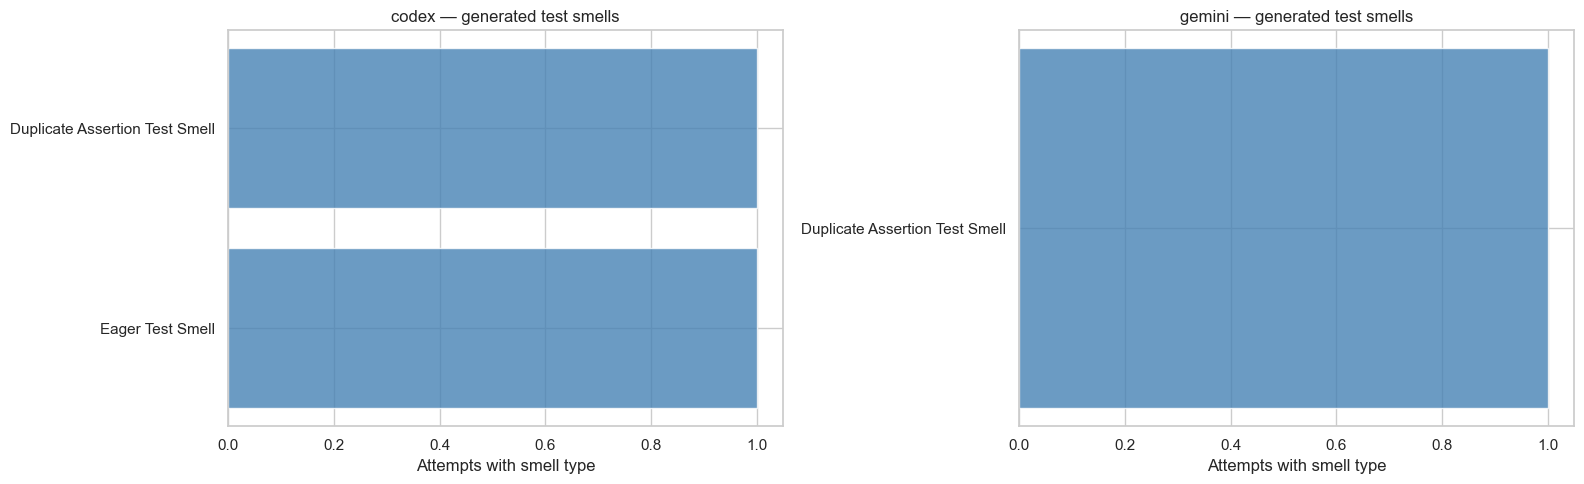

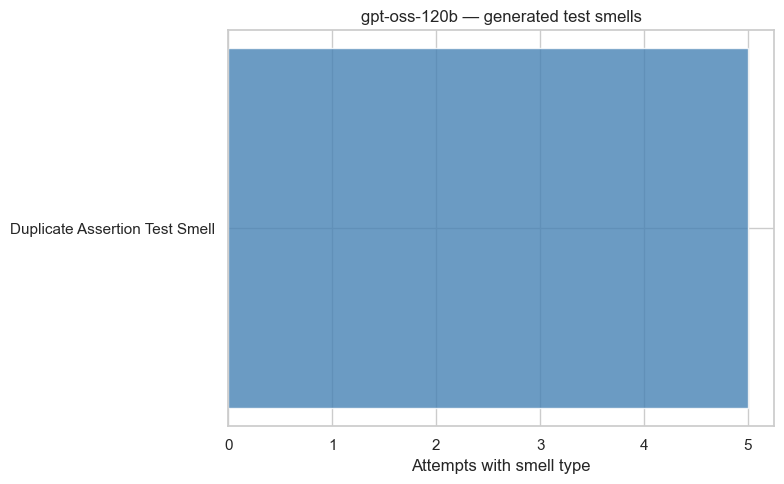

In [11]:
from analysis.plots import smell_type_breakdown

# Smell count by model/tool
for label, df, group_col in [('LLM by model', llm, 'model'), ('Agentic by tool', agentic, 'tool_id')]:
    if group_col not in df.columns or 'generated_test_smell_count' not in df.columns:
        continue
    print(f'{label} — generated test smell counts:')
    display(df.groupby(group_col)['generated_test_smell_count'].agg(['sum', 'mean', 'median']).round(2))
    print()

# Type breakdown per tool (agentic)
if 'tool_id' in agentic.columns and 'generated_test_smell_types' in agentic.columns:
    tools = sorted(agentic['tool_id'].dropna().unique())
    if tools:
        fig, axes = plt.subplots(1, len(tools), figsize=(8 * len(tools), 5), squeeze=False)
        for ax, tool in zip(axes[0], tools):
            smell_type_breakdown(agentic[agentic['tool_id'] == tool], 'generated_test_smell_types', ax=ax)
            ax.set_title(f'{tool} — generated test smells')
        plt.tight_layout()
        plt.show()

# Type breakdown per model (LLM)
if 'model' in llm.columns and 'generated_test_smell_types' in llm.columns:
    models = sorted(llm['model'].dropna().unique())
    if models:
        fig, axes = plt.subplots(1, len(models), figsize=(8 * len(models), 5), squeeze=False)
        for ax, model in zip(axes[0], models):
            smell_type_breakdown(llm[llm['model'] == model], 'generated_test_smell_types', ax=ax)
            ax.set_title(f'{model} — generated test smells')
        plt.tight_layout()
        plt.show()

## 10. Timing and Token Efficiency by Model/Tool

Median generation and validation duration, plus token consumption, broken down per model/tool. Provides the input needed for total-cost calculations and helps identify models that are slow not because of validation but because of generation.


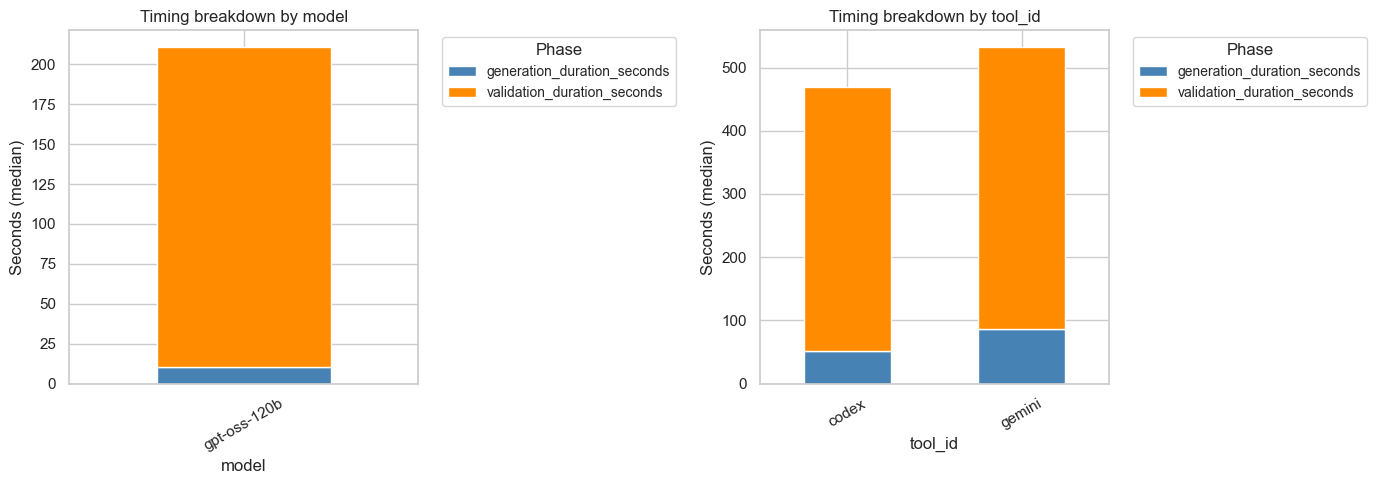


LLM timing/token summary (median):


,total_tokens,generation_duration_seconds,validation_duration_seconds
model,,,
gpt-oss-120b,1818.5,10.1,200.6



Agentic timing/token summary (median):


,total_tokens,generation_duration_seconds,validation_duration_seconds
tool_id,,,
codex,148504.0,51.8,417.5
gemini,166728.5,85.8,446.6


In [12]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'model' in llm.columns:
    timing_stacked_bar(llm, group_col='model', ax=axes[0])
if 'tool_id' in agentic.columns:
    timing_stacked_bar(agentic, group_col='tool_id', ax=axes[1])
plt.tight_layout()
plt.show()

token_cols = [c for c in ['total_tokens', 'generation_duration_seconds', 'validation_duration_seconds']
              if c in attempts.columns]
if token_cols:
    for label, df, group_col in [('LLM', llm, 'model'), ('Agentic', agentic, 'tool_id')]:
        if group_col in df.columns:
            cols_present = [c for c in token_cols if c in df.columns]
            print(f'\n{label} timing/token summary (median):')
            display(df.groupby(group_col)[cols_present].median().round(1))